In [300]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [303]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import os

from fooof import FOOOF

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


In [304]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [305]:
def ranges(nums):
    nums = sorted(set(nums))
    gaps = [[s, e] for s, e in zip(nums, nums[1:]) if s+1 < e]
    edges = iter(nums[:1] + sum(gaps, []) + nums[-1:])
    return list(zip(edges, edges))


In [306]:
def in_burst_to_burst_range_ms(is_burst_array, one_ms):
    """Convert boolean array of whether each idx is in burst, to range of bursts in ms"""
    in_burst_ms = np.where(is_burst_array)[0]

    range_ms = ranges(in_burst_ms.tolist())
    
    return range_ms
    

In [307]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [308]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [309]:
def spk_lfp_class(spk_times_ms, ranges_not_burst_low_ms, gamma_bursts_ms):
    """Classify spikes based on whether they occur during LFP gamma burst 
    or not during gamma oscillations """
    #classify spikes by whether spike time falls in burst group or in low amp no burst group
    spk_class = []
    spk_idx = []
    spk_idx_ms = []

    found = False

    counter = 0

    for spk in spk_times_ms:


        for no_burst in ranges_not_burst_low_ms:


            if no_burst[0]<= spk<=no_burst[1]:

                found = True
                spk_class.append('no_gamma')
                spk_idx_ms.append(spk)
                spk_idx.append(counter)

                break

            else:
                found=False

        if not found:

            for burst in gamma_bursts_ms:


                if burst[0]<= spk<=burst[1]:

                    found = True
                    spk_class.append('gamma')
                    spk_idx_ms.append(spk)
                    spk_idx.append(counter)

                    break

        counter = counter + 1
        
    return spk_class, spk_idx, spk_idx_ms



In [310]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c42 = get_patch_fs_metadata(metadata_dir, 42)
patch_fs_c14 = get_patch_fs_metadata(metadata_dir, 14)

patch_fs = {'c42':patch_fs_c42, 'c14':patch_fs_c14}


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [311]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384
npx_patch_channel = 161

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c14', 'c42']

In [312]:
#load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)
#load in load notebook


## Cell 42  (Whole patch, IC)
### Analze Gamma LFP and whole patch clamp AP relationship for cell 42

### LFP Gamma "burst detection" method

In [313]:
lfp_c42= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_c42 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [352]:
#get cell number 
cell_num = lfp_c42.split('/')[len(lfp_c42.split('/'))-1].split('_')[0]

lfp_filt_c42 = np.load(lfp_c42)
lfp_fs = 2500 # sampling rate
lfp_one_ms = int(lfp_fs / 1000)
lfp_times_c42 = np.arange(0, np.shape(lfp_filt_c42)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt_c42 = np.load(patch_c42)
patch_c42_one_ms = int(patch_fs_c42  / 1000)
patch_times_c42 = np.arange(0, np.shape(patch_filt_c42 )[0]) / patch_c42_one_ms # in ms instead of sec

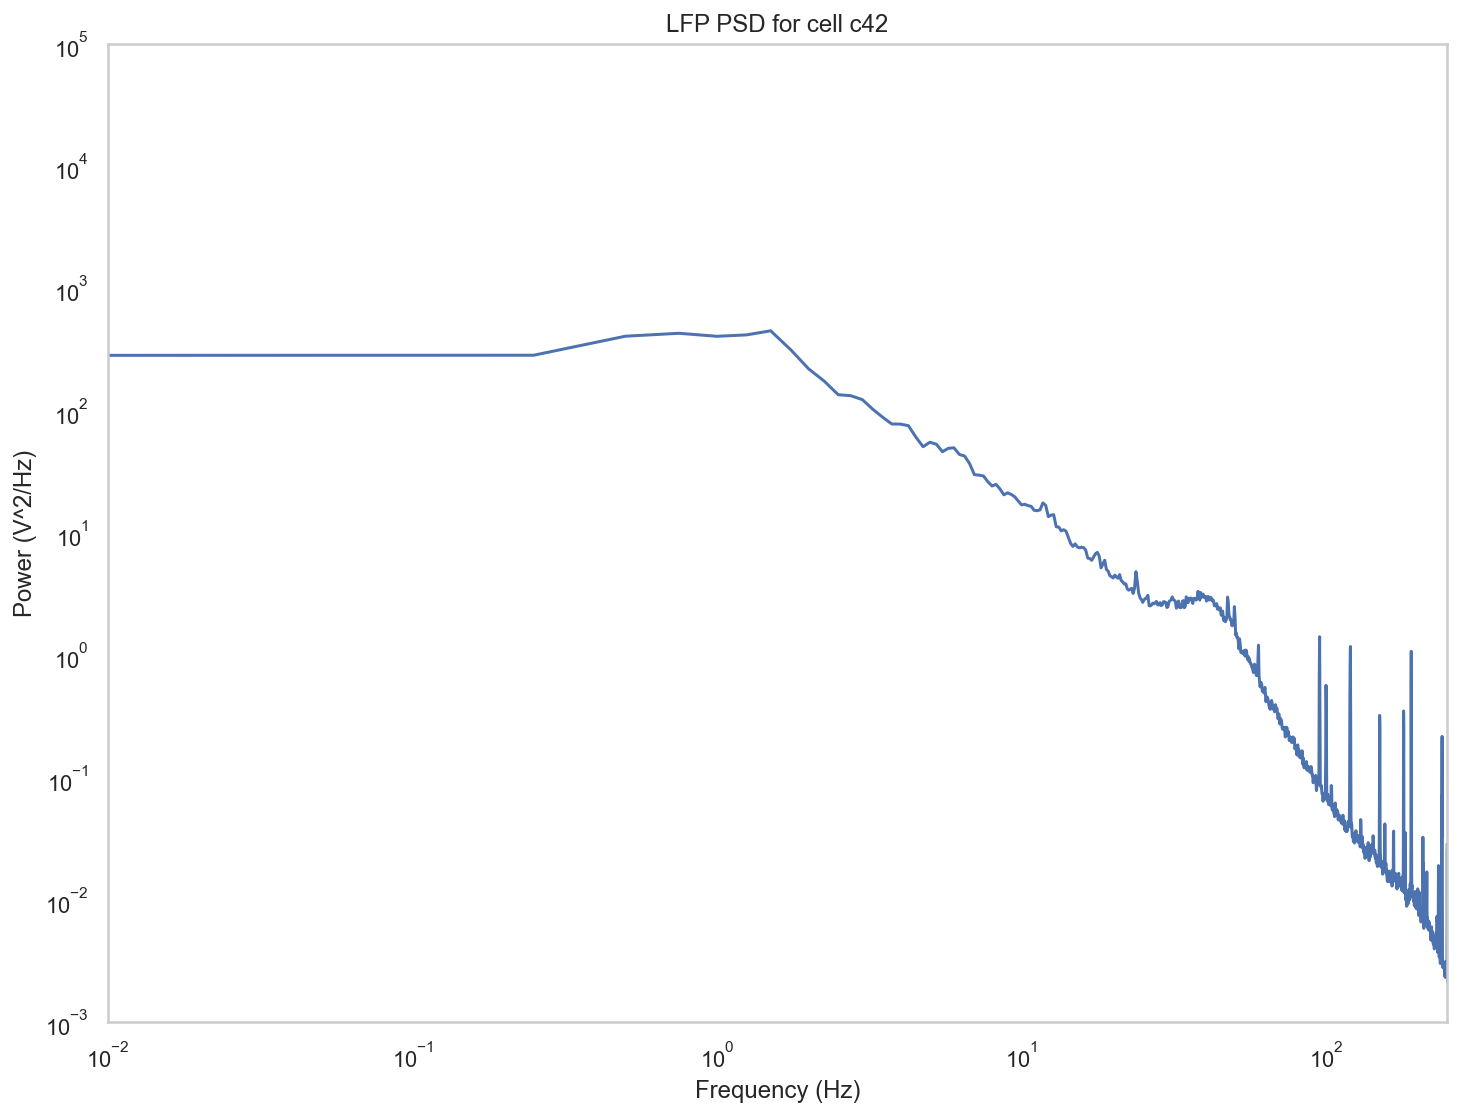

In [315]:
#plot PSD for cell 42
# plot power spectrum
fxx_c42, pxx_c42 = spectral.compute_spectrum(lfp_filt_c42, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx_c42, pxx_c42)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


#### 0. Use specpram to find gamma peaks

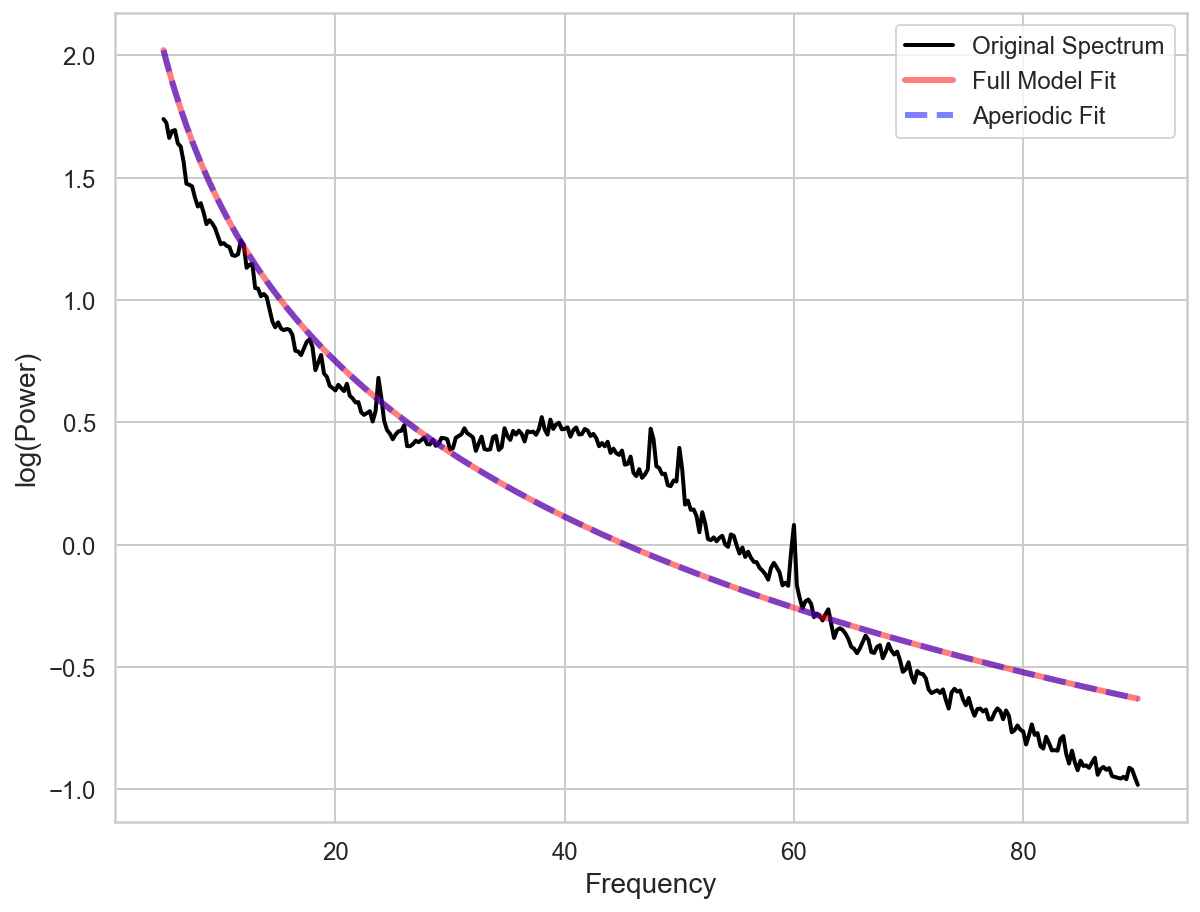

In [316]:
fm_c42 = FOOOF(max_n_peaks=0, verbose=False)
fm_c42.fit(fxx_c42, pxx_c42, freq_range=(5,90))
fm_c42.plot()

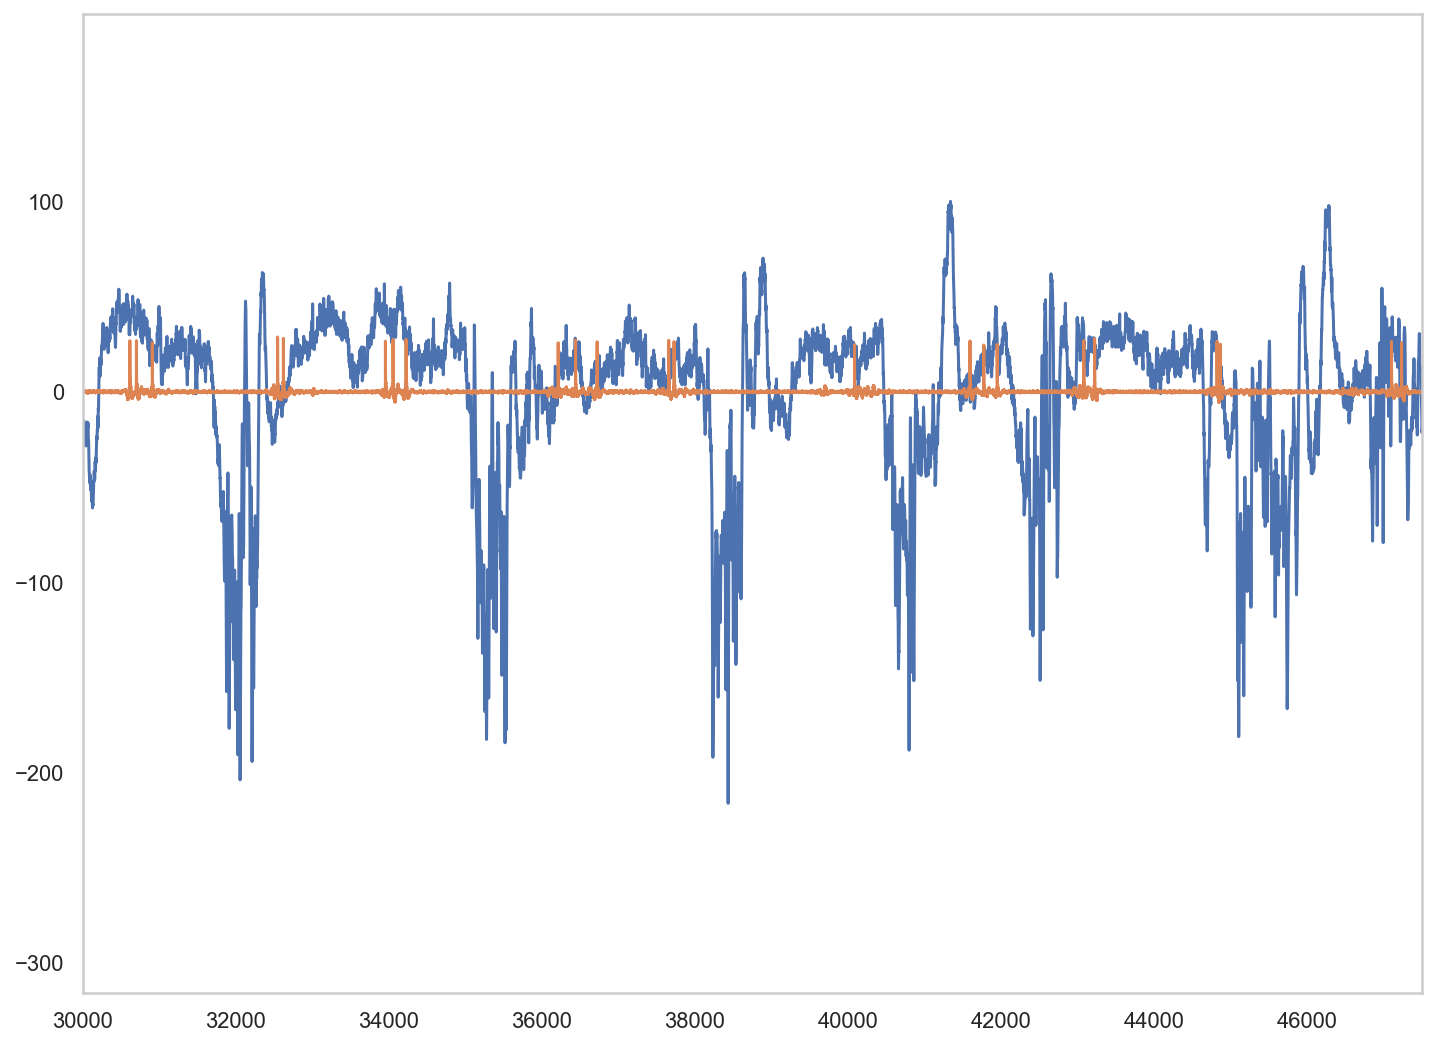

In [317]:
#plot raw LFP and patch data
plt.plot(lfp_times_c42, lfp_filt_c42)
plt.plot(patch_times_c42, patch_filt_c42)
plt.xlim(30000,47500)
plt.show()

#### 1. Filter the signal in +/- 15 Hz around that gamma peak

In [318]:
gamma_peak = 40 #Hz 
gamma_range = [gamma_peak - 15, gamma_peak+15]
#filter LFP data around that range
lfp_filt_gamma_c42 = butter_bandpass(lfp_filt_c42, fs=lfp_fs, filt_freq=gamma_range, order=4)

#### 2. Get the analytic amplitude of the time series 

In [319]:
gamma_amp = amp_by_time(lfp_filt_gamma_c42, lfp_fs, gamma_range)

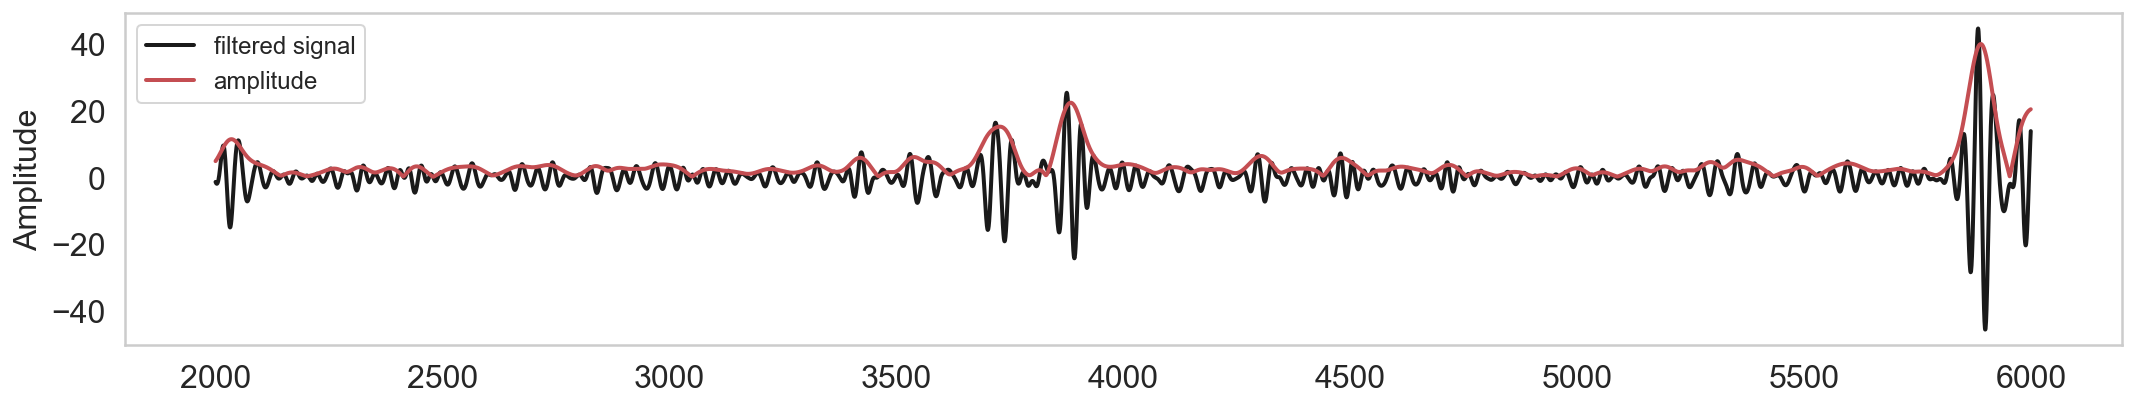

In [320]:
xlim = (2000, 6000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

# Plot the filtered signal and oscillation amplitude
plot_instantaneous_measure(lfp_times_c42[tidx], [lfp_filt_gamma_c42[tidx], gamma_amp[tidx]],
                           measure='amplitude', lw=2, xlabel='',
                           labels=['filtered signal', 'amplitude'])

#### 3. Classify a burst as whenever the gamma analytic amplitude goes above some criterion (3x median, 2std of the mean, whatever), and ends when it drops below another criterion (1.5x mean, 1std of mean)


#### Try 3 different moethods for gamma burst classifcation
#### Method 1: My own code to detect when analytic amplitude goes above some criteria
#### Method 2: neurodsp burst detection on gamma filtered data
#### Method 3: neurodsp burst detection on unfiltered data 

#### Method 1

In [321]:
bthresh_start  = 3*np.nanmean(gamma_amp)
bthresh_end  = 1.5*np.nanmean(gamma_amp)

In [322]:
gamma_bursts = []
gamma_bursts_ms_m1 = [] #instead of indeces, ranges for gamma bursts are in ms 
inburst_list = []


start_burst=False

#classify bursts following thresholds 
for i in range(len(lfp_times_c42)):
    
    if start_burst:
        inburst_list.append(True)

    else:
        inburst_list.append(False)

    if np.abs(lfp_filt_gamma_c42[i])>bthresh_start:
        start_burst = True
        start_idx = i
        
        
        
    elif np.abs(lfp_filt_gamma_c42[i])<bthresh_end and start_burst:
        end_idx = i
        
        gamma_bursts.append([start_idx, end_idx])
        
        start_idx_ms = start_idx/lfp_one_ms
        end_idx_ms = end_idx/lfp_one_ms
        
        gamma_bursts_ms_m1.append([start_idx_ms, end_idx_ms])
        
        start_burst = False
       
        
        
    
        
        
        
        


In [323]:
gamma_bursts_ms_m1


[[244.5, 249.5],
 [299.5, 303.0],
 [567.5, 570.0],
 [582.0, 584.0],
 [594.0, 596.0],
 [606.5, 609.5],
 [1782.0, 1784.0],
 [1798.0, 1803.0],
 [1819.0, 1825.0],
 [3702.5, 3707.0],
 [3721.0, 3727.0],
 [3741.5, 3745.0],
 [3860.5, 3864.5],
 [3880.5, 3882.5],
 [3896.5, 3899.0],
 [3908.0, 3912.0],
 [5871.5, 5873.5],
 [5889.5, 5890.5],
 [5906.0, 5907.5],
 [5923.0, 5927.0],
 [5976.0, 5979.5],
 [5991.5, 5994.0],
 [6006.0, 6009.0],
 [6021.5, 6024.0],
 [6035.0, 6038.0],
 [6233.0, 6236.5],
 [6252.0, 6254.5],
 [6268.5, 6272.0],
 [6810.5, 6812.5],
 [6825.0, 6827.0],
 [6836.5, 6839.0],
 [7498.5, 7504.0],
 [7517.5, 7522.0],
 [7608.5, 7611.0],
 [7625.0, 7627.0],
 [7639.0, 7643.5],
 [9198.5, 9200.5],
 [9213.5, 9215.5],
 [9228.0, 9231.0],
 [9959.0, 9961.5],
 [9974.5, 9976.0],
 [9989.5, 9991.0],
 [10004.0, 10006.0],
 [10017.0, 10020.0],
 [11300.0, 11305.0],
 [11454.5, 11457.0],
 [11471.5, 11473.5],
 [11488.0, 11490.5],
 [11504.5, 11510.0],
 [13061.0, 13065.0],
 [13084.0, 13087.0],
 [13098.5, 13100.5],
 [13

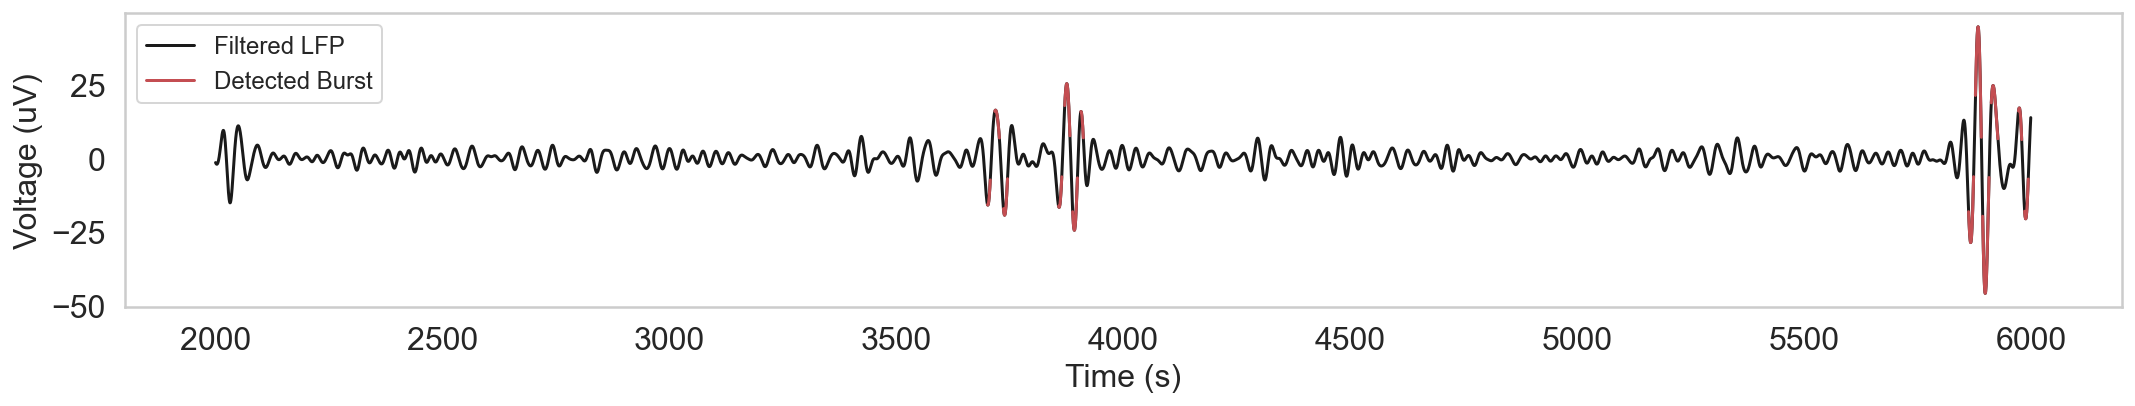

In [324]:
# Plot signal and burst activity
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], np.asarray(inburst_list)[tidx], labels=['Filtered LFP', 'Detected Burst'])


#### Method 2

In [325]:
xlim = (1000,20000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

In [326]:
###Try neurodsp burst detection method 
is_burst_gamma = detect_bursts_dual_threshold(lfp_filt_c42, lfp_fs, dual_thresh=(3, 1), f_range=(gamma_peak - 15, gamma_peak+15))


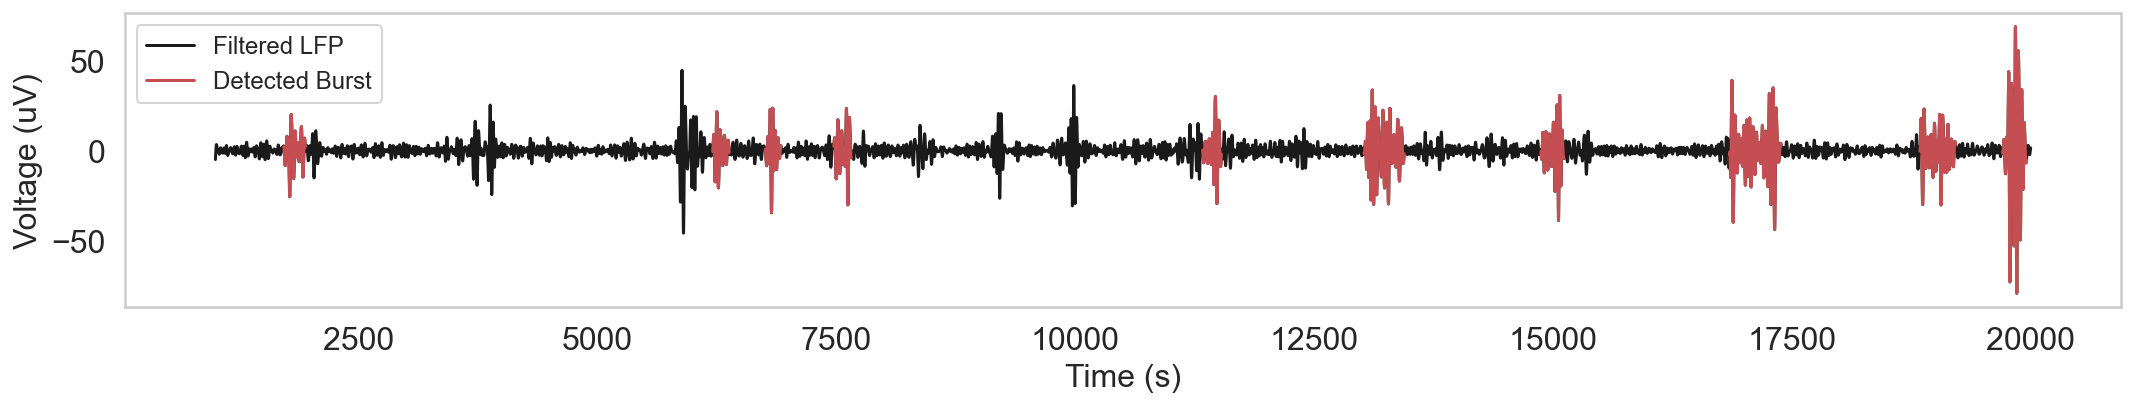

In [327]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_gamma[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [328]:
gamma_bursts_ms_m2 = in_burst_to_burst_range_ms(is_burst_gamma, lfp_one_ms)

TypeError: 'int' object is not callable

#### Method 3

In [ ]:
###Try neurodsp burst detection method 
is_burst = detect_bursts_dual_threshold(lfp_filt_gamma_c42, lfp_fs, dual_thresh=(2, 1), f_range=(gamma_peak - 15, gamma_peak+15))


In [ ]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [ ]:
gamma_bursts_ms_m3 = in_burst_to_burst_range_ms(is_burst, lfp_one_ms)

### Load and analyze extracellular spike data

In [ ]:
# load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c42npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = int(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109


In [ ]:
# open and load the data
npx_filt = np.load(npx_path)

In [ ]:
plt.plot(npx_filt[0:100000])

#### Detect extracellular spikes

In [ ]:
sp_ex = Spike(thresh_amp=41.5, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)

In [ ]:
sp_ex.df_features

In [ ]:
sp_ex.plot()

In [ ]:
sp_ex.spike_inds

### Compute patch clamp spike features for cell 42

#### 4. compare the patched spike waveform for spikes that occur during an obvious gamma burst versus those are are obviously not in gamma. We’ll want to confirm this visually, looking at the time series as well.


In [ ]:
#load patch clamp data for cell 42
patch_filt_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'
patch_fs = 50023.88170476
patch_one_ms = int(patch_fs / 1000)

In [ ]:
patch_filt = np.load(patch_filt_dir)
patch_times = np.arange(0, np.shape(patch_filt)[0]) / patch_one_ms # in ms instead of sec


In [ ]:
plt.plot(patch_times, patch_filt)

In [ ]:
plt.plot(patch_times[10000:1000000], patch_filt[10000:1000000])

In [ ]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=18, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

In [ ]:
sp.df_features

In [ ]:
# First 100 fits
sp.plot(inds=np.arange(800))

### Use detected spike indeces to determine if a spike occured during gamma peak or not

#### A) Get converted indices for gamma 'bursts'

In [ ]:
gamma_bursts_ms_m3

#### B) Get converted indices for lowest amp no gamma 'bursts'. Select areas not in bursts with the lowest analytic amplitude

In [ ]:
is_not_burst_gamma = np.where(is_burst_gamma == False)[0]

In [ ]:
ranges_not_burst = ranges(is_not_burst_gamma.tolist())

#### Select ranges with lowest analytical amplitude 

In [ ]:
no_burst_mean_amp = []
no_burst_mean_ranges = []

for r in ranges_not_burst:
    
    am_range = gamma_amp[slice(*r)]
    #take mean of analytic amplitude for that range 
    mean_am = np.nanmean(am_range)
    no_burst_mean_amp.append(mean_am)
    no_burst_mean_ranges.append(r)
    


In [ ]:
#Select 25% no burst sections with lowest analytical amplitude 
n_lowest = int(len(no_burst_mean_amp) * 0.25)
no_burst_mean_amp_array = np.array(no_burst_mean_amp, dtype=np.float32)
lowest_amp_no_bursts = no_burst_mean_amp_array.argsort()[:n_lowest]

#get the index range of the sections with lowest amplitude 
ranges_not_burst_low =  [ranges_not_burst[i] for i in lowest_amp_no_bursts]

#convert to ms
ranges_not_burst_low_ms = [(x*lfp_one_ms, y*lfp_one_ms) for x,y in ranges_not_burst_low]



#### C) Determine what spikes are in which group 

In [ ]:
spk_times_ms = patch_times_c42[sp.spike_inds]

In [329]:
spk_class, spk_idx, spk_idx_ms =  spk_lfp_class(spk_times_ms, ranges_not_burst_low_ms, gamma_bursts_ms_m3)


In [330]:
occurrence = {item: spk_class.count(item) for item in spk_class}

In [331]:
occurrence

{'gamma': 123, 'no_gamma': 212}

#### E) Compare features of gamma and no gamma spikes

In [332]:
#Get features for gamma spikes
idx_gamma = np.where(np.array(spk_class) == 'gamma')[0]
#get spike_idx 
spk_idx_gamma = np.asarray(spk_idx)[np.asarray(idx_gamma)]
spk_gamma_features = sp.df_features.iloc[spk_idx_gamma]

In [333]:
#Get features for no gamma spikes
idx_no_gamma = np.where(np.array(spk_class) == 'no_gamma')[0]
#get spike_idx 
spk_idx_no_gamma = np.asarray(spk_idx)[np.asarray(idx_no_gamma)]
spk_no_gamma_features = sp.df_features.iloc[spk_idx_no_gamma]

##### Gamma features

In [334]:
spk_gamma_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
2,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,966.738253,0.951638,0.987640
35,1.319995,0.74,0.824109,24.956773,1.18,0.671016,6.263786,10.543570,4.257966,0.967473,0.016963
36,0.027284,0.94,2.368575,27.579293,1.82,0.320663,1.137511,8.667136,0.000000,0.005998,0.998102
37,0.027284,0.94,2.368575,27.579293,1.82,0.320663,1.137511,8.667136,980.791541,0.005998,0.998102
76,0.531008,0.74,-4.851704,18.848800,1.14,0.698719,1.397989,-5.047072,9.675379,0.811283,0.998030
...,...,...,...,...,...,...,...,...,...,...,...
721,0.091547,0.88,2.554623,18.985937,1.54,0.211781,0.797600,2.659829,0.000000,0.071076,0.998912
722,0.091547,0.88,2.554623,18.985937,1.54,0.211781,0.797600,2.659829,114.765184,0.071076,0.998912
723,0.724534,1.00,1.032759,19.357923,1.68,0.319943,0.735566,2.011817,0.000000,0.805005,0.998326
724,0.724534,1.00,1.032759,19.357923,1.68,0.319943,0.735566,2.011817,382.317392,0.805005,0.998326


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/internals/blocks.py:402: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


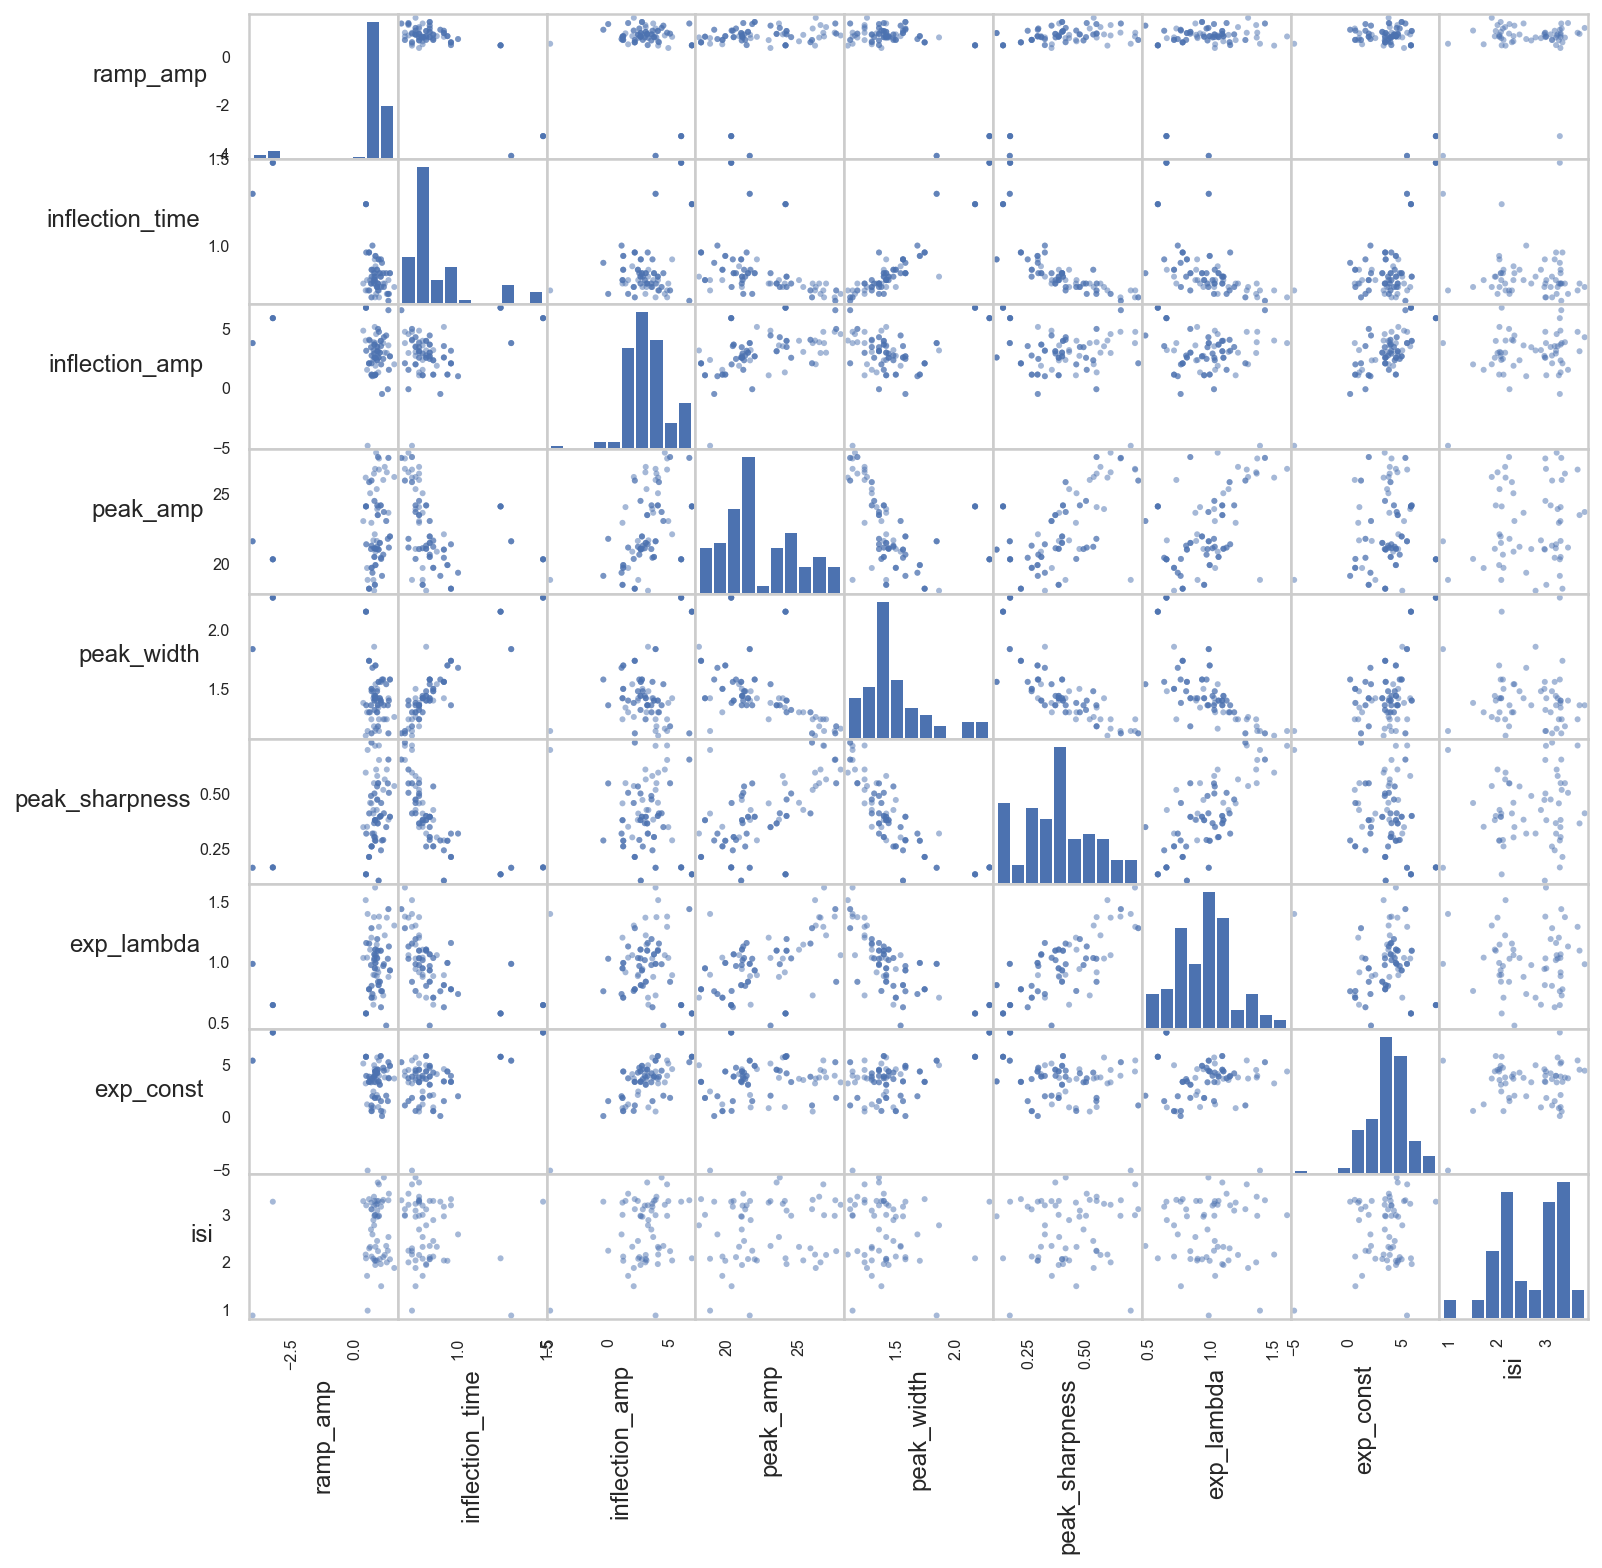

In [335]:
# Ensure inflection times are between 0 and 2 ms
df_drop_gamma = spk_gamma_features.loc[spk_gamma_features['inflection_time'] > 0.]
df_drop_gamma = df_drop_gamma.loc[df_drop_gamma['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_gamma = df_drop_gamma.loc[df_drop_gamma['r_squared_exp']  >= .5]
df_drop_gamma = df_drop_gamma.loc[df_drop_gamma['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_gamma[['isi']] = np.log10(df_drop_gamma[['isi']])

# drop no-longer-used QC features
df_drop_gamma = df_drop_gamma.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_gamma = df_drop_gamma.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_gamma, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

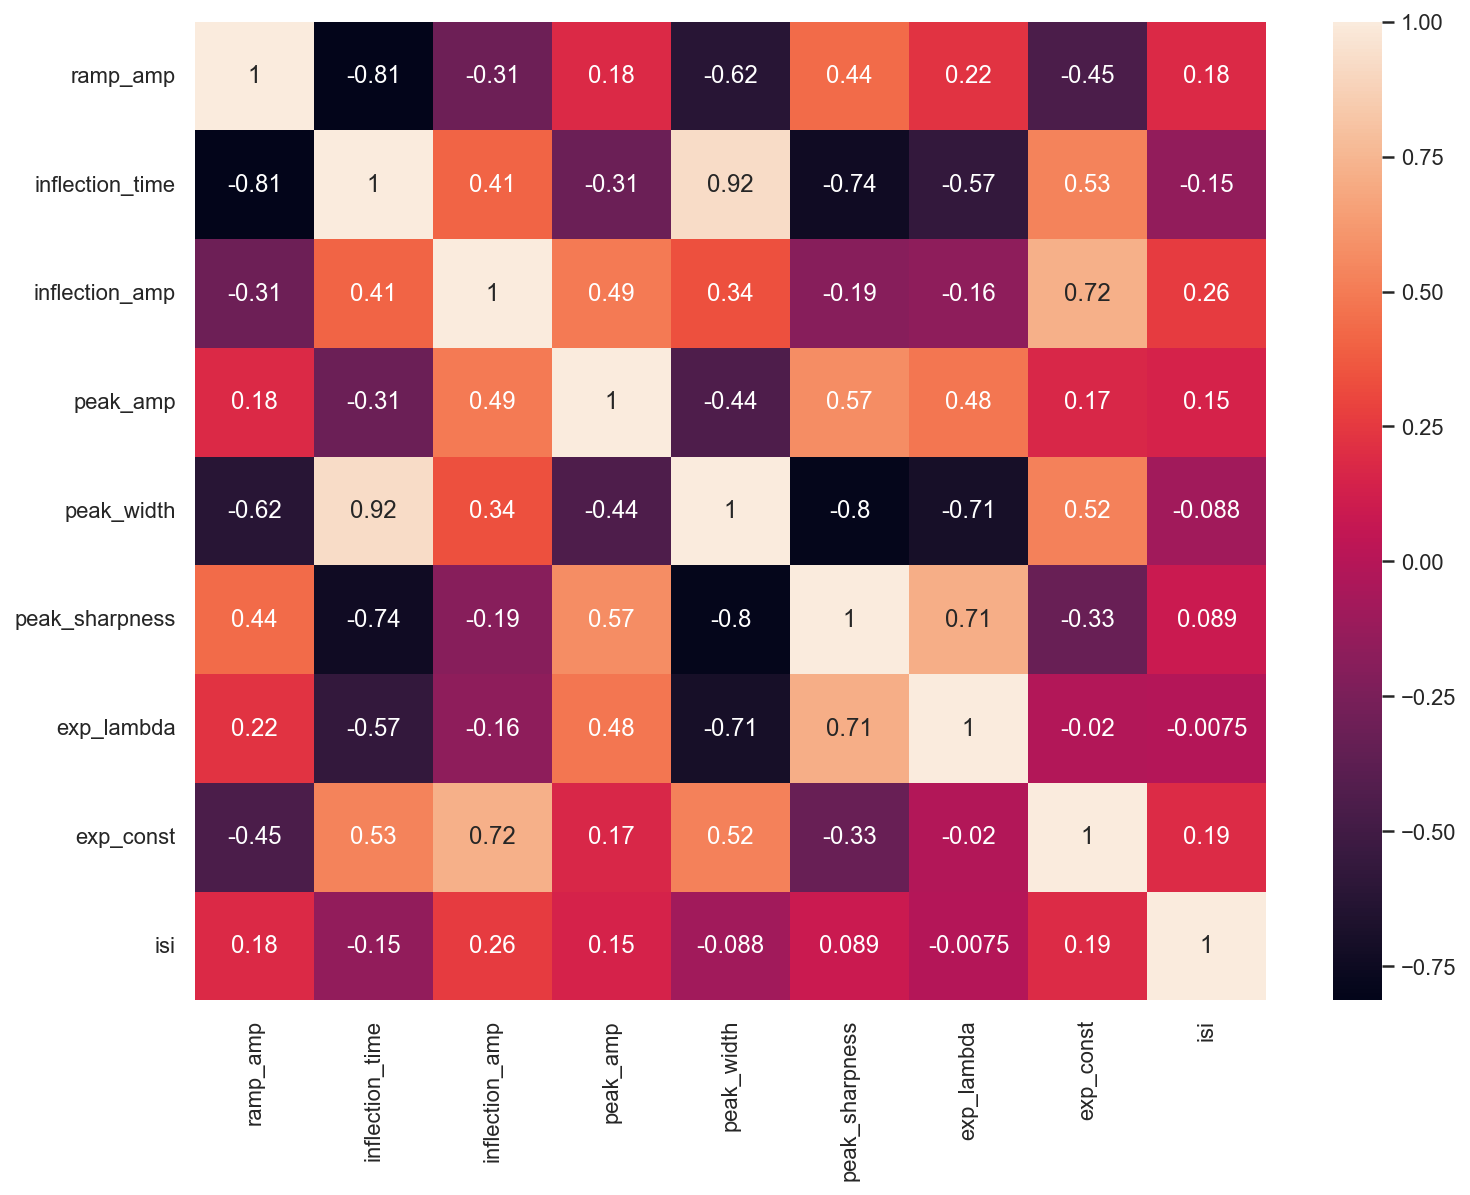

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi
ramp_amp,1.0***,-0.81***,-0.31***,0.18,-0.62***,0.44***,0.22*,-0.45***,0.18
inflection_time,-0.81***,1.0***,0.41***,-0.31***,0.92***,-0.74***,-0.57***,0.53***,-0.15
inflection_amp,-0.31***,0.41***,1.0***,0.49***,0.34***,-0.19*,-0.16,0.72***,0.26*
peak_amp,0.18,-0.31***,0.49***,1.0***,-0.44***,0.57***,0.48***,0.17,0.15
peak_width,-0.62***,0.92***,0.34***,-0.44***,1.0***,-0.8***,-0.71***,0.52***,-0.09
peak_sharpness,0.44***,-0.74***,-0.19*,0.57***,-0.8***,1.0***,0.71***,-0.33***,0.09
exp_lambda,0.22*,-0.57***,-0.16,0.48***,-0.71***,0.71***,1.0***,-0.02,-0.01
exp_const,-0.45***,0.53***,0.72***,0.17,0.52***,-0.33***,-0.02,1.0***,0.19
isi,0.18,-0.15,0.26*,0.15,-0.09,0.09,-0.01,0.19,1.0***


In [336]:
spikes_corr_gamma = df_drop_gamma.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma, xticklabels=spikes_corr_gamma.columns, 
            yticklabels=spikes_corr_gamma.columns, annot=True)
plt.show()

rho = df_drop_gamma.corr()
pval = df_drop_gamma.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

##### No gamma features

In [337]:
spk_no_gamma_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
183,1.155178,0.78,1.896664,25.316572,1.26,0.379166,1.245614,2.782131,0.000000,0.951455,0.997716
184,1.155178,0.78,1.896664,25.316572,1.26,0.379166,1.245614,2.782131,147.109735,0.951455,0.997716
185,0.871254,0.76,1.638711,23.508618,1.24,0.562298,0.997393,1.222785,1172.020203,0.943358,0.991777
186,1.499805,0.76,-0.162200,23.692297,1.36,0.685179,1.321254,3.924568,101.571486,0.952682,0.999024
187,1.171112,0.70,2.196991,24.479508,1.26,0.563319,1.282073,3.558143,0.000000,0.941639,0.998679
...,...,...,...,...,...,...,...,...,...,...,...
821,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,0.000000,0.964008,0.998475
822,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,0.000000,0.964008,0.998475
823,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,0.000000,0.964008,0.998475
824,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,0.000000,0.964008,0.998475


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/internals/blocks.py:402: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


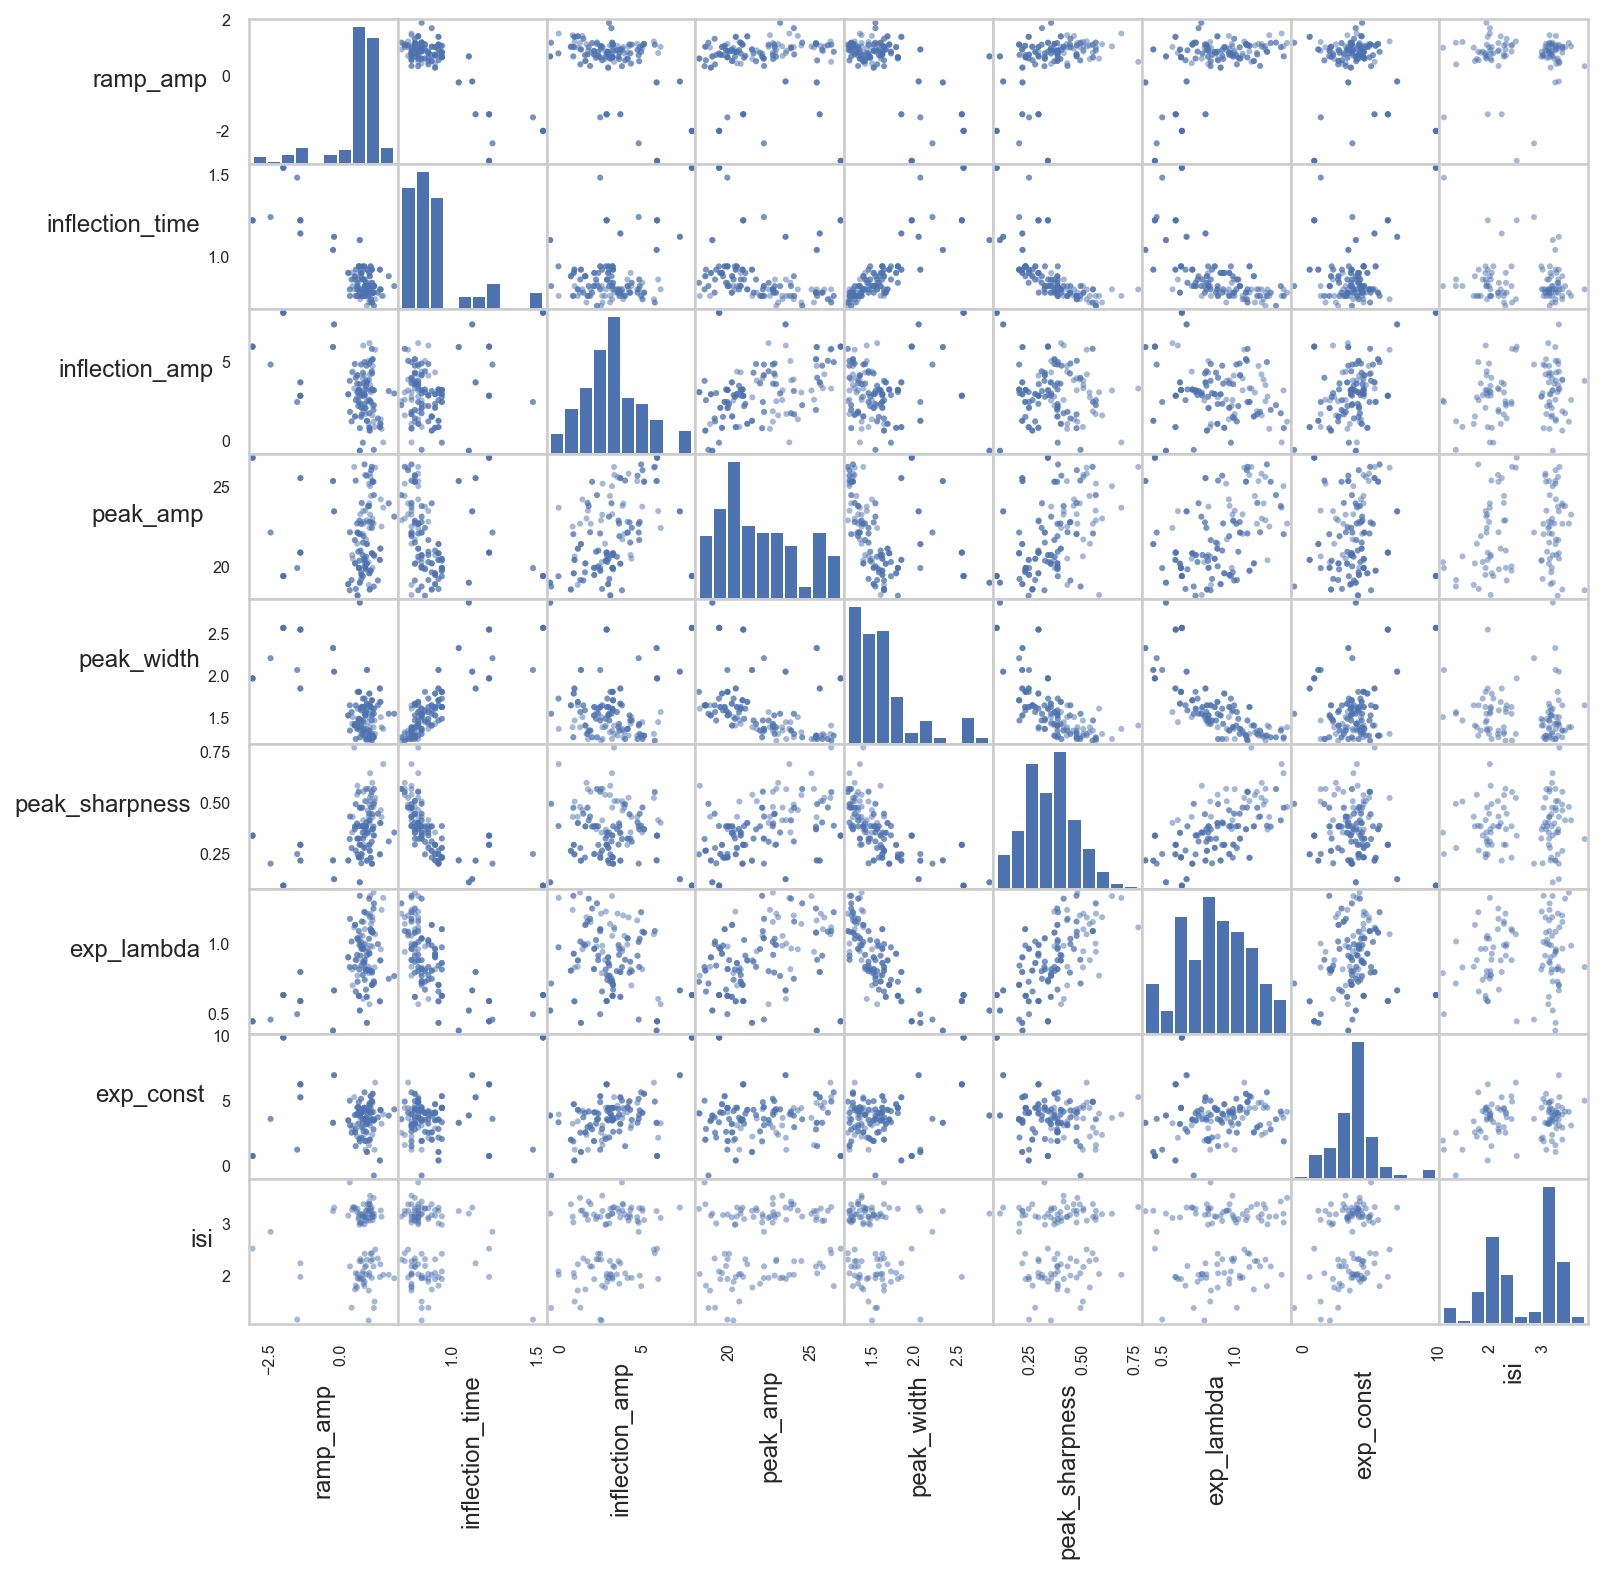

In [338]:
# Ensure inflection times are between 0 and 2 ms
df_drop_no_gamma = spk_no_gamma_features.loc[spk_no_gamma_features['inflection_time'] > 0.]
df_drop_no_gamma = df_drop_no_gamma.loc[df_drop_no_gamma['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_no_gamma = df_drop_no_gamma.loc[df_drop_no_gamma['r_squared_exp']  >= .5]
df_drop_no_gamma = df_drop_no_gamma.loc[df_drop_no_gamma['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_no_gamma[['isi']] = np.log10(df_drop_no_gamma[['isi']])

# drop no-longer-used QC features
df_drop_no_gamma = df_drop_no_gamma.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_no_gamma = df_drop_no_gamma.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_no_gamma, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

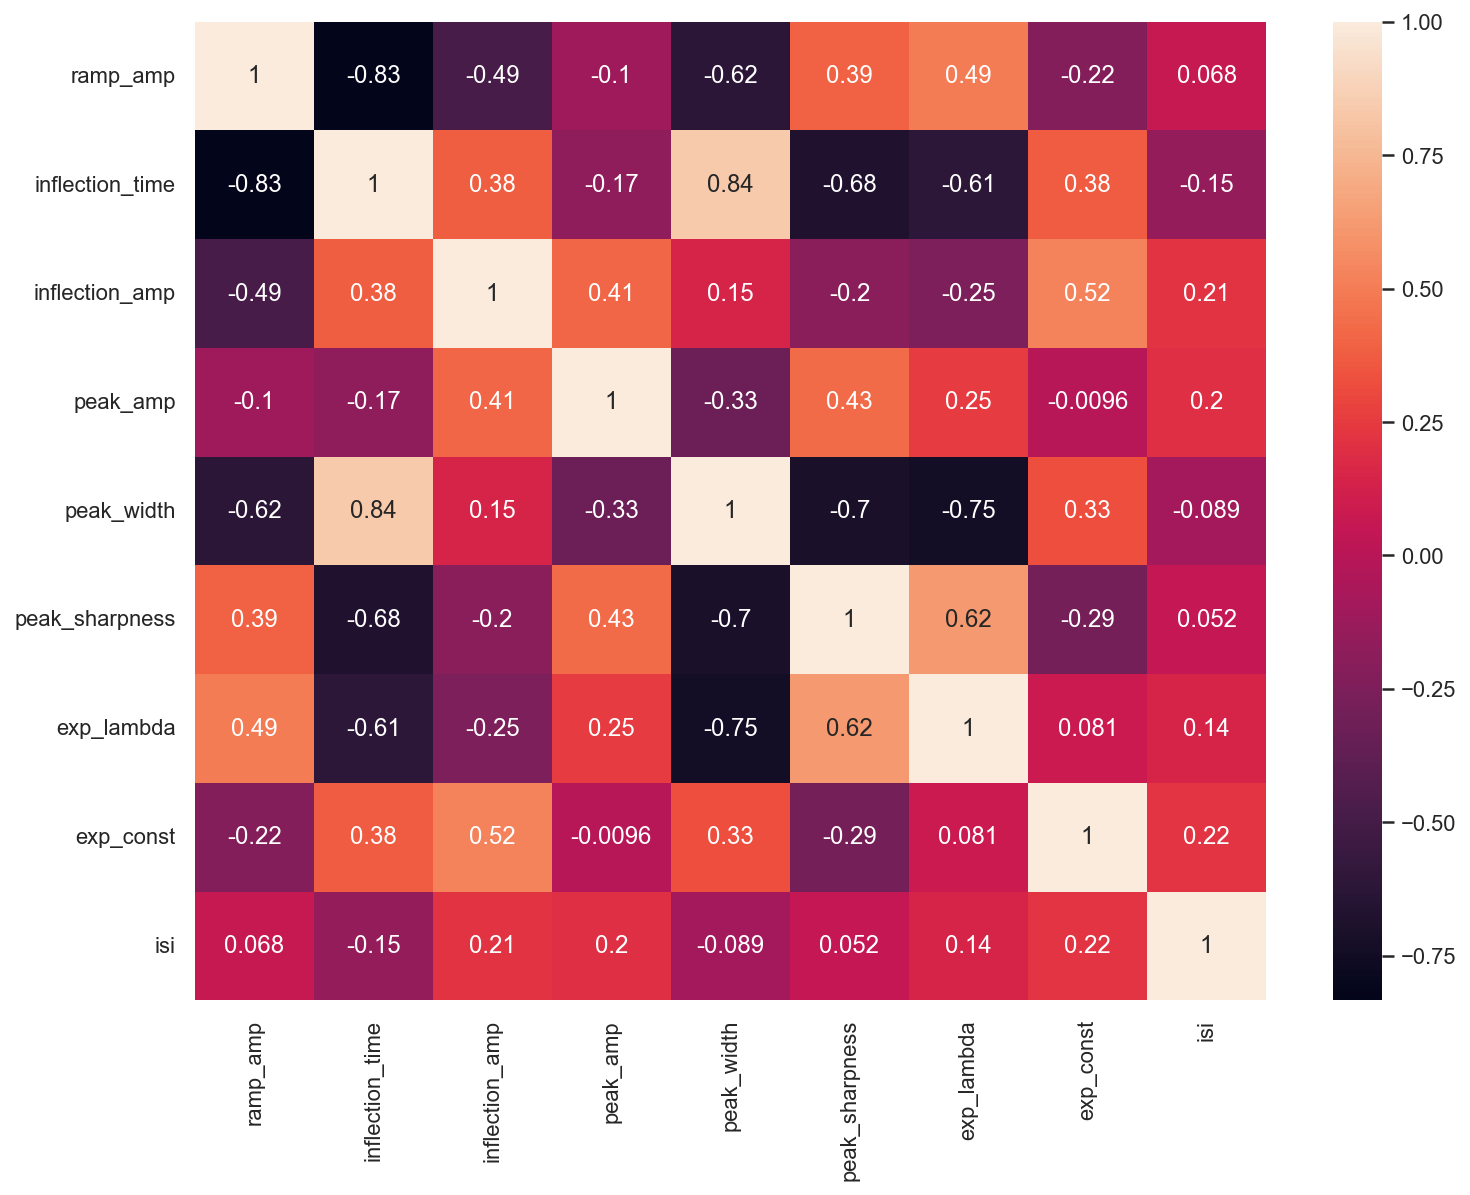

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi
ramp_amp,1.0***,-0.83***,-0.49***,-0.1,-0.62***,0.39***,0.49***,-0.22**,0.07
inflection_time,-0.83***,1.0***,0.38***,-0.17*,0.84***,-0.68***,-0.61***,0.38***,-0.15
inflection_amp,-0.49***,0.38***,1.0***,0.41***,0.15*,-0.2**,-0.25***,0.52***,0.21*
peak_amp,-0.1,-0.17*,0.41***,1.0***,-0.33***,0.43***,0.25***,-0.01,0.2*
peak_width,-0.62***,0.84***,0.15*,-0.33***,1.0***,-0.7***,-0.75***,0.33***,-0.09
peak_sharpness,0.39***,-0.68***,-0.2**,0.43***,-0.7***,1.0***,0.62***,-0.29***,0.05
exp_lambda,0.49***,-0.61***,-0.25***,0.25***,-0.75***,0.62***,1.0***,0.08,0.14
exp_const,-0.22**,0.38***,0.52***,-0.01,0.33***,-0.29***,0.08,1.0***,0.22*
isi,0.07,-0.15,0.21*,0.2*,-0.09,0.05,0.14,0.22*,1.0***


In [339]:
spikes_corr_no_gamma = df_drop_no_gamma.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma, xticklabels=spikes_corr_no_gamma.columns, 
            yticklabels=spikes_corr_no_gamma.columns, annot=True)
plt.show()

rho = df_drop_no_gamma.corr()
pval = df_drop_no_gamma.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [340]:
df_drop_gamma

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi
2,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.985309
76,0.531008,0.74,-4.851704,18.848800,1.14,0.698719,1.397989,-5.047072,0.985668
80,-4.085151,1.30,3.835460,21.601920,1.84,0.165229,0.985077,5.394517,NaN
81,-4.085151,1.30,3.835460,21.601920,1.84,0.165229,0.985077,5.394517,NaN
82,-4.085151,1.30,3.835460,21.601920,1.84,0.165229,0.985077,5.394517,0.882886
...,...,...,...,...,...,...,...,...,...
717,0.844887,0.94,1.173485,19.904714,1.70,0.287536,0.992663,4.363107,NaN
718,0.844887,0.94,1.173485,19.904714,1.70,0.287536,0.992663,4.363107,2.029987
723,0.724534,1.00,1.032759,19.357923,1.68,0.319943,0.735566,2.011817,NaN
724,0.724534,1.00,1.032759,19.357923,1.68,0.319943,0.735566,2.011817,2.582424


In [341]:
df_drop_no_gamma

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi
183,1.155178,0.78,1.896664,25.316572,1.26,0.379166,1.245614,2.782131,NaN
184,1.155178,0.78,1.896664,25.316572,1.26,0.379166,1.245614,2.782131,2.167641
185,0.871254,0.76,1.638711,23.508618,1.24,0.562298,0.997393,1.222785,3.068935
186,1.499805,0.76,-0.162200,23.692297,1.36,0.685179,1.321254,3.924568,2.006772
187,1.171112,0.70,2.196991,24.479508,1.26,0.563319,1.282073,3.558143,NaN
...,...,...,...,...,...,...,...,...,...
821,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,NaN
822,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,NaN
823,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,NaN
824,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,NaN


##### Compare features between gamma and no gamma spike groups (initial descriptive)

In [342]:
columns = df_drop_gamma.columns.values.tolist()

In [343]:
df_drop_gamma.mean()

ramp_amp            0.579288
inflection_time     0.877876
inflection_amp      3.120164
peak_amp           22.256159
peak_width          1.497522
peak_sharpness      0.380994
exp_lambda          0.957907
exp_const           3.618905
isi                 2.654420
dtype: float64

In [344]:
df_drop_no_gamma.mean()

ramp_amp            0.513984
inflection_time     0.896337
inflection_amp      3.118242
peak_amp           21.813878
peak_width          1.625446
peak_sharpness      0.345387
exp_lambda          0.865224
exp_const           3.770276
isi                 2.632892
dtype: float64

In [345]:
df_drop_gamma.std()

ramp_amp           1.186003
inflection_time    0.187871
inflection_amp     1.789544
peak_amp           2.592069
peak_width         0.282314
peak_sharpness     0.154001
exp_lambda         0.232721
exp_const          1.947718
isi                0.660125
dtype: float64

In [346]:
df_drop_no_gamma.std()

ramp_amp           1.006539
inflection_time    0.179142
inflection_amp     1.819320
peak_amp           2.358890
peak_width         0.360486
peak_sharpness     0.123460
exp_lambda         0.231584
exp_const          1.745076
isi                0.651132
dtype: float64

##### Stats for compared features

In [347]:
# Combine group dataframes into one df with a tag column
groups = {'gamma': df_drop_gamma, 'no_gamma': df_drop_no_gamma}
df_concate_ggroups = pd.concat(groups, names=['LFP_class'])
df_concate_ggroups = df_concate_ggroups.reset_index(level=0)



In [348]:
df_concate_ggroups

,LFP_class,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi
2,gamma,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.985309
76,gamma,0.531008,0.74,-4.851704,18.848800,1.14,0.698719,1.397989,-5.047072,0.985668
80,gamma,-4.085151,1.30,3.835460,21.601920,1.84,0.165229,0.985077,5.394517,NaN
81,gamma,-4.085151,1.30,3.835460,21.601920,1.84,0.165229,0.985077,5.394517,NaN
82,gamma,-4.085151,1.30,3.835460,21.601920,1.84,0.165229,0.985077,5.394517,0.882886
...,...,...,...,...,...,...,...,...,...,...
821,no_gamma,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,NaN
822,no_gamma,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,NaN
823,no_gamma,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,NaN
824,no_gamma,-2.028283,1.54,8.051293,19.411701,2.56,0.090120,0.632347,9.823941,NaN


##### Run t-tests for variables

In [349]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups[c][df_concate_ggroups['LFP_class'] == 'gamma'],
                    df_concate_ggroups[c][df_concate_ggroups['LFP_class'] == 'no_gamma'], nan_policy='omit'))

ramp_amp t-test
Ttest_indResult(statistic=0.51750431359265, pvalue=0.6051696952597667)
inflection_time t-test
Ttest_indResult(statistic=-0.8619548381957771, pvalue=0.3893722513623268)
inflection_amp t-test
Ttest_indResult(statistic=0.009042077247269506, pvalue=0.9927913248067326)
peak_amp t-test
Ttest_indResult(statistic=1.5399230471919978, pvalue=0.12458943573658361)
peak_width t-test
Ttest_indResult(statistic=-3.254313862525752, pvalue=0.0012610046270295709)
peak_sharpness t-test
Ttest_indResult(statistic=2.2422229014874633, pvalue=0.025646983573998226)
exp_lambda t-test
Ttest_indResult(statistic=3.4008370337978757, pvalue=0.0007589376249085482)
exp_const t-test
Ttest_indResult(statistic=-0.7079259655742796, pvalue=0.47951805048199425)
isi t-test
Ttest_indResult(statistic=0.20180466519050586, pvalue=0.8403273943817161)


##### Compare cross correlation matrices

In [350]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma), upper(spikes_corr_no_gamma)))

SignificanceResult(statistic=0.9585585585585585, pvalue=4.0704602079603025e-20)


##### Data is not independent so using this pvalues is misleading. To test for significance, 

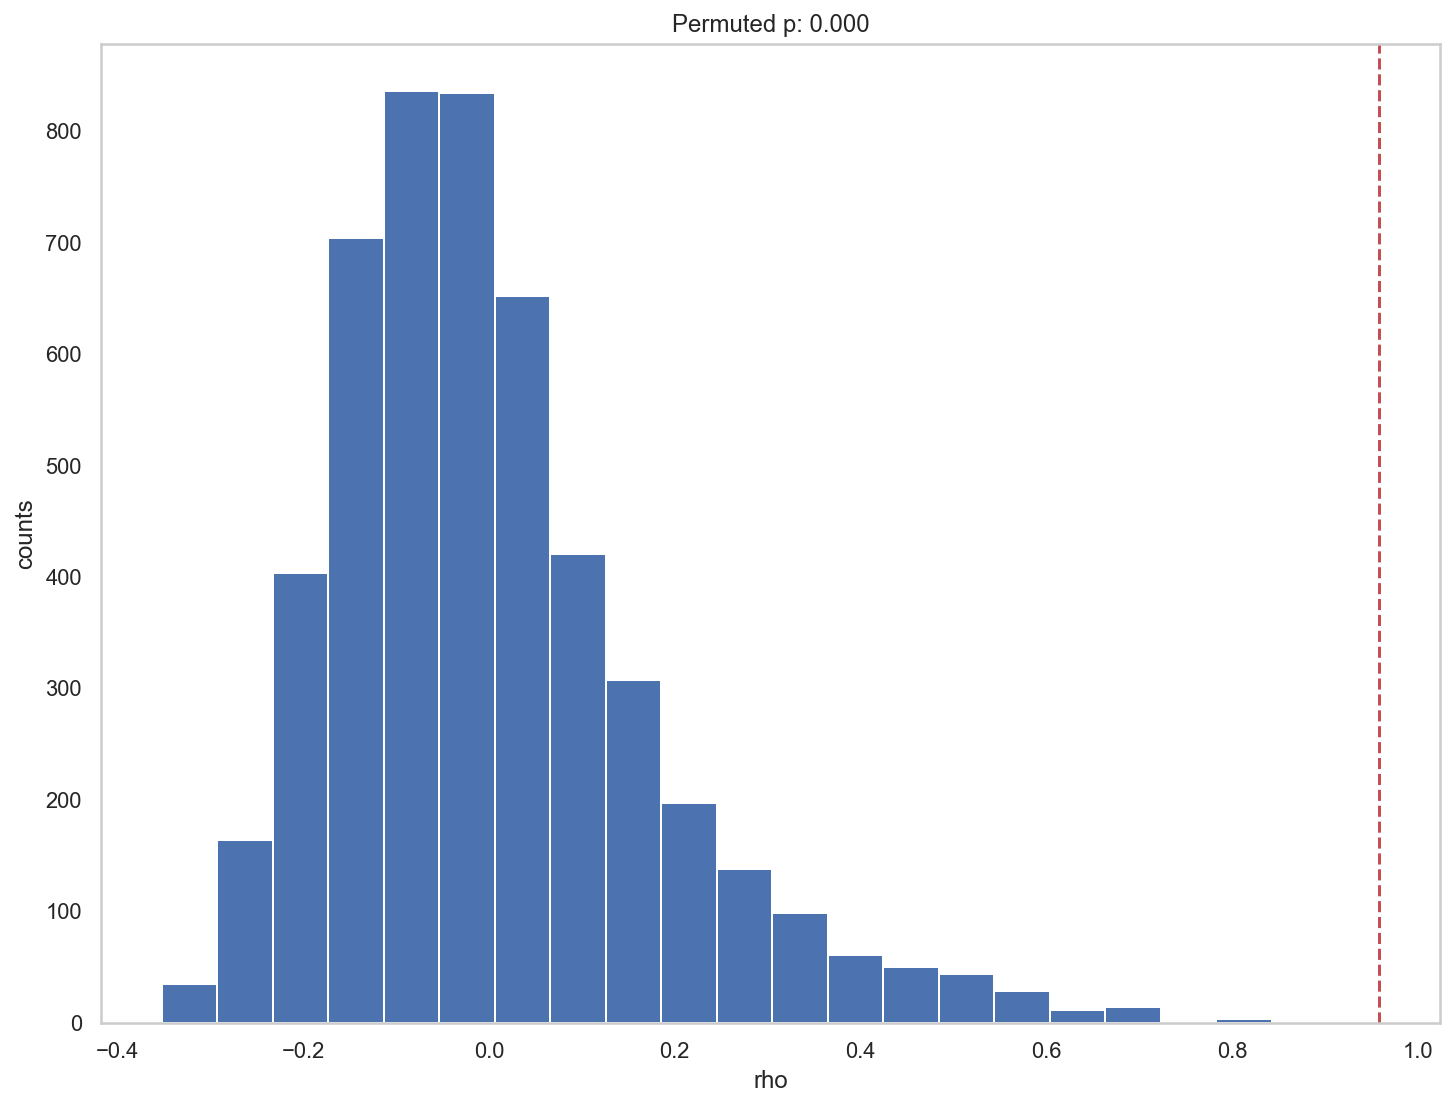

In [351]:
"""Nonparametric permutation testing Monte Carlo"""
np.random.seed(0)
rhos = []
n_iter = 5000
true_rho, _ = stats.spearmanr(upper(spikes_corr_gamma), upper(spikes_corr_no_gamma))
# matrix permutation, shuffle the groups
m_ids = list(spikes_corr_gamma.columns)
m2_v = upper(spikes_corr_no_gamma)
for iter in range(n_iter):
  np.random.shuffle(m_ids) # shuffle list 
  r, _ = stats.spearmanr(upper(spikes_corr_gamma.loc[m_ids, m_ids]), m2_v)  
  rhos.append(r)
perm_p = ((np.sum(np.abs(true_rho) <= np.abs(rhos)))+1)/(n_iter+1) # two-tailed test


f,ax = plt.subplots()
plt.hist(rhos,bins=20)
ax.axvline(true_rho,  color = 'r', linestyle='--')
ax.set(title=f"Permuted p: {perm_p:.3f}", ylabel="counts", xlabel="rho")
plt.show()

##### Cross-correlation matrices are significantly similar :()